# Brightness under each technique: 3D true vs 3D stitched, region by region

Section 7 of `segmentation_method_comparison.ipynb` walks every FOV in a
region under both techniques and scores them on *mask shape* — how far masks
reach through z, how steadily they change size. This notebook walks the same
FOVs, region by region, and asks what the mask geometry cannot: **do the voxels
a technique claims actually look like signal?**

Every voxel contributes one `(brightness, is_masked)` pair — each pixel column
`(y, x)` vectorised across z, so a technique's decision is scored plane by plane
rather than object by object. A technique picking up nuclei puts bright voxels
inside its masks and leaves dim ones outside. One that over-grows its masks
drags background in, and its masked distribution slides left toward the
unmasked one.

## The figure

One figure per FOV, two panels:

* **left** — voxels *in* a mask, one curve per technique
* **right** — voxels *not* in a mask, one curve per technique

This is the opposite split from the single-run figure in
`segmentation_z_brightness_claude.py`, where the two panels were masked vs
unmasked for one technique. Here each panel holds one of those groups and the
*techniques* are overlaid inside it, because the comparison being made is
between techniques — and a difference is far easier to read as two curves on one
axes than as two panels side by side.

Each curve is normalised within its own (technique, panel) group. That matters:
masked voxels are a few percent of a volume and unmasked voxels are the rest, so
raw counts would only ever show that one group is enormous.

Both techniques segment the **same DAPI stack**, so the stack is read once per
FOV, the bins are built from it once, and both mask volumes are histogrammed
onto them — two distributions binned differently cannot be laid over each other.
Across FOVs the bins do differ, so `SHARE_X` pins every figure in a region to
one axis and the stack of them reads down as well as across.

## Reading it

`auc` is the headline: **P(a random masked voxel is brighter than a random
unmasked one)** within that run. 0.5 says brightness carries no information about
what the technique masked; 1.0 says every masked voxel outshines every unmasked
one. It is the one number that survives the two groups being wildly different
sizes, so it compares techniques and FOVs directly — but read it next to
`frac_masked`, because a technique can post a high AUC by masking only the very
brightest voxels and skipping most of the nuclei.

`segmentation_brightness_helpers.py` is only the comparison layer: the
measurement comes from `segmentation_z_brightness_claude.py` and the region walk
and palette from `segmentation_z_helpers.py`, so a technique keeps its colour
across both notebooks.

In [5]:
from pathlib import Path

import pandas as pd

import segmentation_z_helpers as h
import segmentation_brightness_helpers as bh

h.apply_theme()   # same figure style as the other notebook
pd.set_option("display.width", 140)

ModuleNotFoundError: No module named 'salk'

### Config

`TECHNIQUE_ROOTS` points at the directory *above* the region under each
technique tree, exactly as in section 7. `DAPI_PATCHES` is the matching patches
directory — each region block appends its own region name to it, since that is
the image both techniques segmented.

In [1]:
DATA_ROOT = Path("data")

FAMILY = "cpdino"
PREPROCESSING = "decon"
MODEL = "VePo"

TECHNIQUE_ROOTS = {
    "3D true":     DATA_ROOT / "segmentations_3d_true"     / FAMILY / PREPROCESSING / MODEL,
    "3D stitched": DATA_ROOT / "segmentations_3d_stitched" / FAMILY / PREPROCESSING / MODEL,
}
DAPI_PATCHES = DATA_ROOT / "patches" / MODEL

N_DISPLAY_BINS = 60
CLIP_QUANTILE = 0.999   # x axis stops at this quantile of the pooled brightness
SHARE_X = True          # one brightness axis across every FOV in the region
SHARE_Y = False          # one height across both panels; False lets each autoscale
LOG_Y = False           # worth flipping when a peak flattens the tails

METRIC_COLUMNS = ["frac_masked", "median_masked", "median_unmasked",
                  "auc", "point_biserial_r"]

print("available:", ", ".join(h.available_regions(TECHNIQUE_ROOTS)))

NameError: name 'Path' is not defined

### Region UCI-2424

In [13]:
# --- 1a. every FOV in the region, under both techniques ----------------------
SCAN_REGION = "region_UCI-2424"

found = h.find_region_fovs(TECHNIQUE_ROOTS, SCAN_REGION)
print(f"\n{found['fov'].nunique()} paired FOV(s) in {SCAN_REGION}\n")

runs = bh.scan_region_brightness(found, DAPI_PATCHES / SCAN_REGION)
metrics = bh.brightness_metrics(runs)

metrics[METRIC_COLUMNS].round(3)


3 paired FOV(s) in region_UCI-2424

  fov_01     3D true       3,348,836 masked voxels ( 2.99%)
  fov_01     3D stitched   4,622,260 masked voxels ( 4.13%)
  fov_07     3D true      29,695,128 masked voxels (26.51%)
  fov_07     3D stitched  39,117,517 masked voxels (34.93%)
  fov_09     3D true      19,761,817 masked voxels (17.64%)
  fov_09     3D stitched  39,355,639 masked voxels (35.14%)


frac_masked  median_masked  median_unmasked    auc  point_biserial_r
fov    method                                                                           
fov_01 3D true            0.030      11114.035          213.413  0.977             0.834
       3D stitched        0.041       8077.047          213.221  0.909             0.746
fov_07 3D true            0.265      14103.208         1149.434  0.975             0.830
       3D stitched        0.349      11867.063         1069.203  0.924             0.734
fov_09 3D true            0.176      15643.891         1147.807  0.954             0.774
       3D stitched        0.351       7281.459         1284.593  0.704             0.502

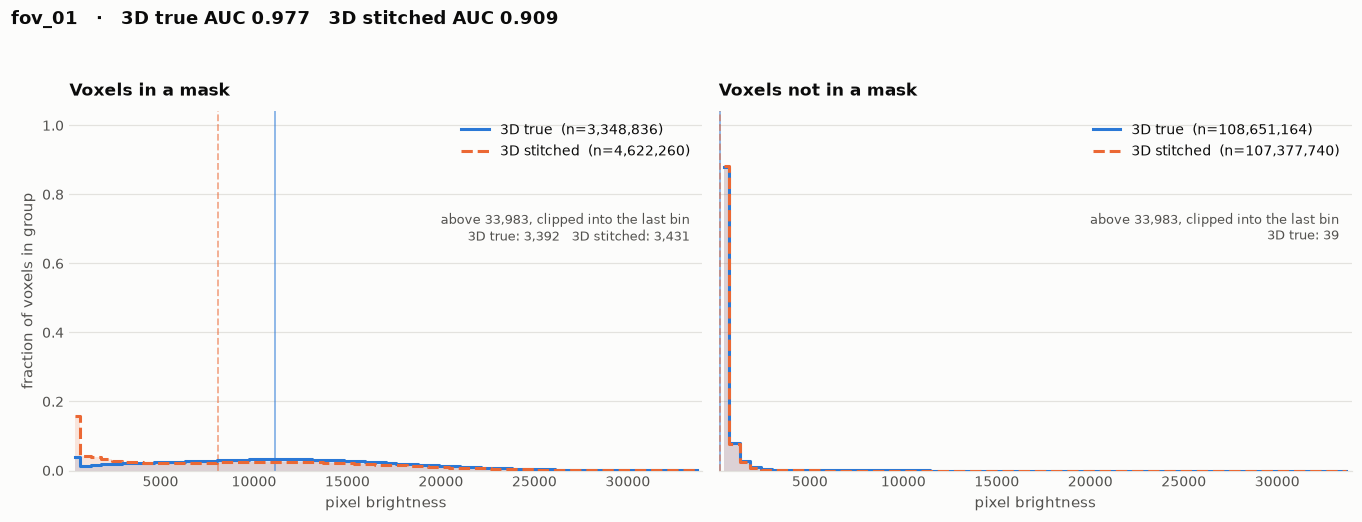

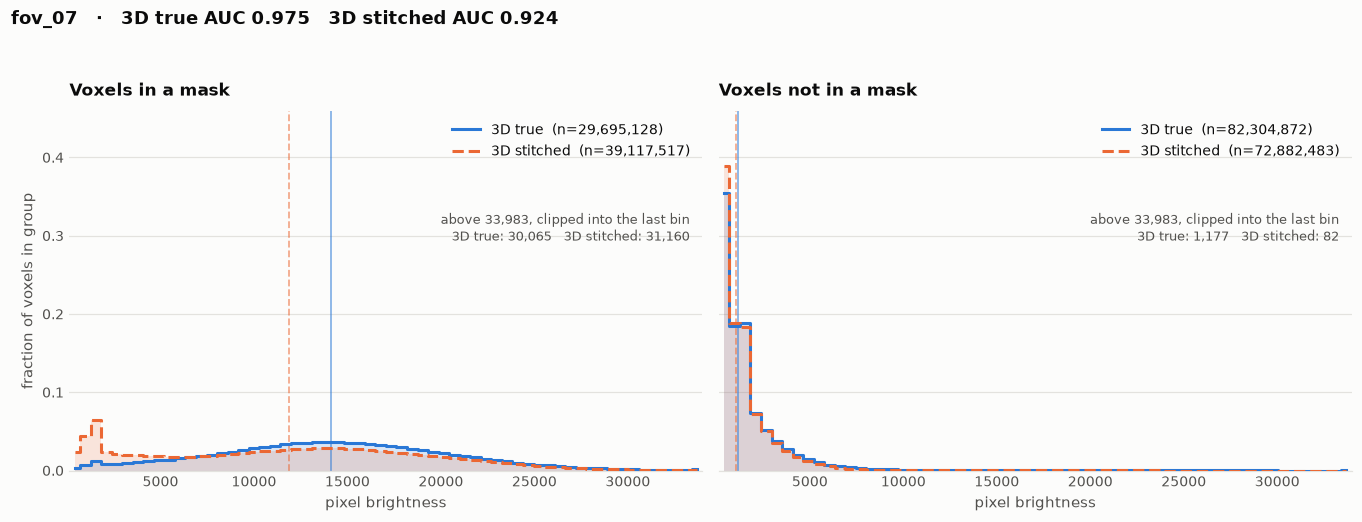

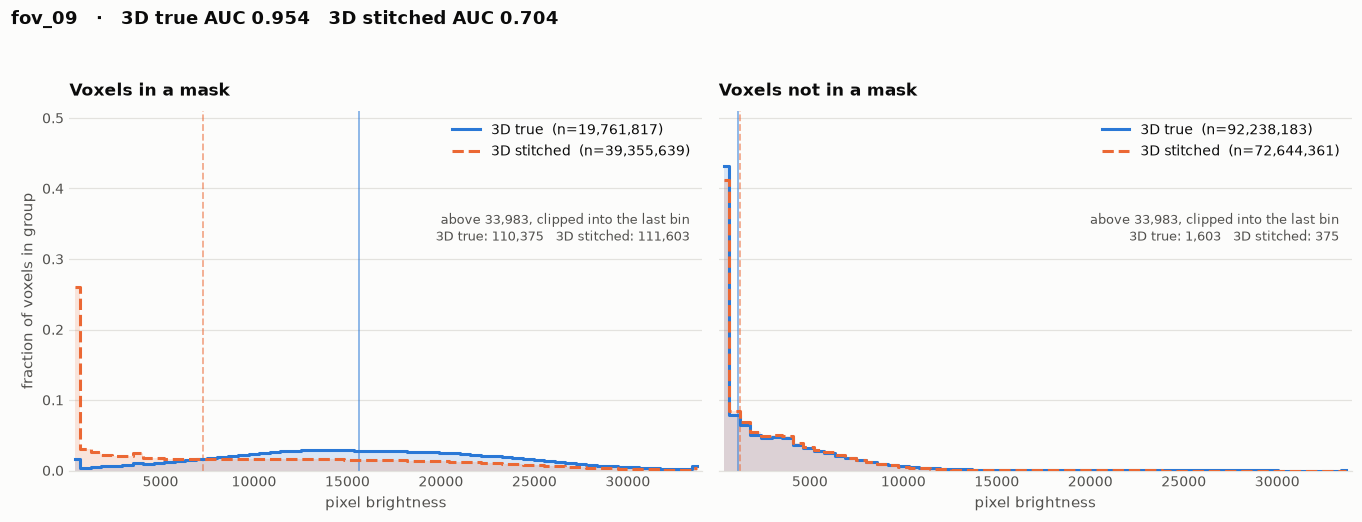

In [14]:
# --- 1b. one figure per FOV ---------------------------------------------------
figures = bh.plot_region_brightness(
    runs, metrics=metrics,
    share_x=SHARE_X, share_y=SHARE_Y,
    n_bins=N_DISPLAY_BINS, clip_quantile=CLIP_QUANTILE, log_y=LOG_Y,
)

### Region UCI-4723

In [15]:
# --- 2a. every FOV in the region, under both techniques ----------------------
SCAN_REGION = "region_UCI-4723"

found = h.find_region_fovs(TECHNIQUE_ROOTS, SCAN_REGION)
print(f"\n{found['fov'].nunique()} paired FOV(s) in {SCAN_REGION}\n")

runs = bh.scan_region_brightness(found, DAPI_PATCHES / SCAN_REGION)
metrics = bh.brightness_metrics(runs)

metrics[METRIC_COLUMNS].round(3)


3 paired FOV(s) in region_UCI-4723

  fov_01     3D true         895,216 masked voxels ( 0.80%)
  fov_01     3D stitched   1,575,532 masked voxels ( 1.41%)
  fov_04     3D true      11,245,829 masked voxels (10.04%)
  fov_04     3D stitched  15,756,472 masked voxels (14.07%)
  fov_07     3D true      29,538,856 masked voxels (26.37%)
  fov_07     3D stitched  42,329,258 masked voxels (37.79%)


frac_masked  median_masked  median_unmasked    auc  point_biserial_r
fov    method                                                                           
fov_01 3D true            0.008      13140.524          189.222  0.986             0.849
       3D stitched        0.014       6189.810          189.039  0.889             0.694
fov_04 3D true            0.100      16327.453          235.205  0.990             0.867
       3D stitched        0.141      13055.288          226.113  0.958             0.788
fov_07 3D true            0.264      14182.894         2251.643  0.961             0.805
       3D stitched        0.378      10868.430         2064.888  0.887             0.678

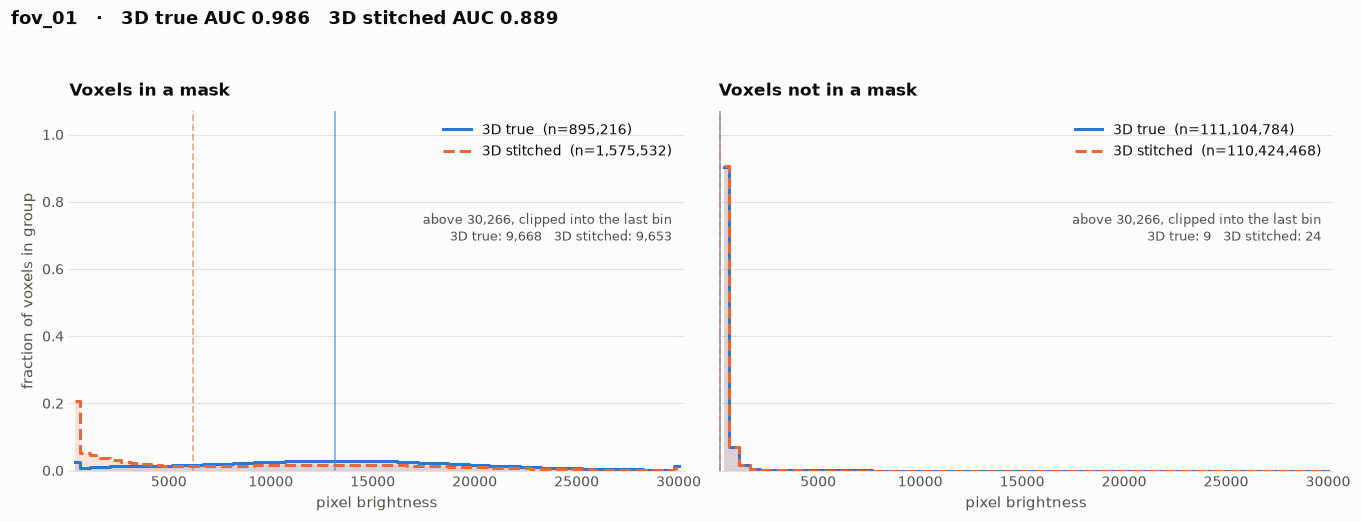

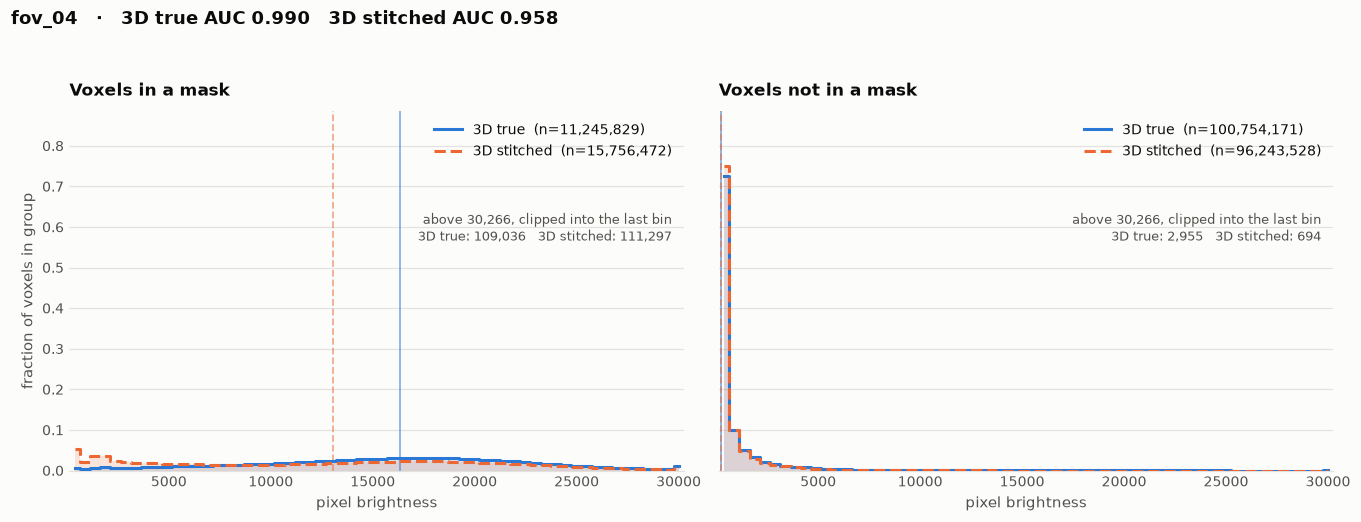

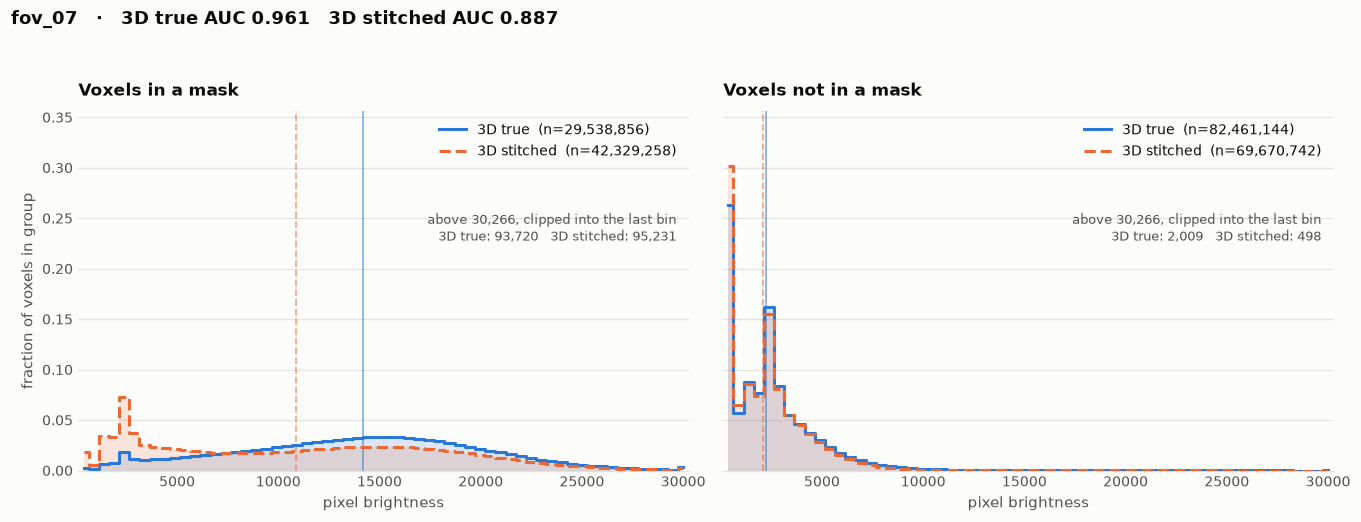

In [16]:
# --- 2b. one figure per FOV ---------------------------------------------------
figures = bh.plot_region_brightness(
    runs, metrics=metrics,
    share_x=SHARE_X, share_y=SHARE_Y,
    n_bins=N_DISPLAY_BINS, clip_quantile=CLIP_QUANTILE, log_y=LOG_Y,
)

### Region UCI-5224

In [17]:
# --- 3a. every FOV in the region, under both techniques ----------------------
SCAN_REGION = "region_UCI-5224"

found = h.find_region_fovs(TECHNIQUE_ROOTS, SCAN_REGION)
print(f"\n{found['fov'].nunique()} paired FOV(s) in {SCAN_REGION}\n")

runs = bh.scan_region_brightness(found, DAPI_PATCHES / SCAN_REGION)
metrics = bh.brightness_metrics(runs)

metrics[METRIC_COLUMNS].round(3)


3 paired FOV(s) in region_UCI-5224

  fov_04     3D true      22,392,241 masked voxels (19.99%)
  fov_04     3D stitched  30,743,976 masked voxels (27.45%)
  fov_06     3D true      14,317,597 masked voxels (12.78%)
  fov_06     3D stitched  21,299,384 masked voxels (19.02%)
  fov_07     3D true      34,059,544 masked voxels (30.41%)
  fov_07     3D stitched  46,158,968 masked voxels (41.21%)


frac_masked  median_masked  median_unmasked    auc  point_biserial_r
fov    method                                                                           
fov_04 3D true            0.200      13487.442          580.362  0.974             0.822
       3D stitched        0.274      10738.164          466.829  0.927             0.729
fov_06 3D true            0.128      14892.446          520.568  0.982             0.840
       3D stitched        0.190      11087.375          444.670  0.928             0.738
fov_07 3D true            0.304      14805.655         1954.207  0.962             0.814
       3D stitched        0.412      12011.653         1948.970  0.877             0.681

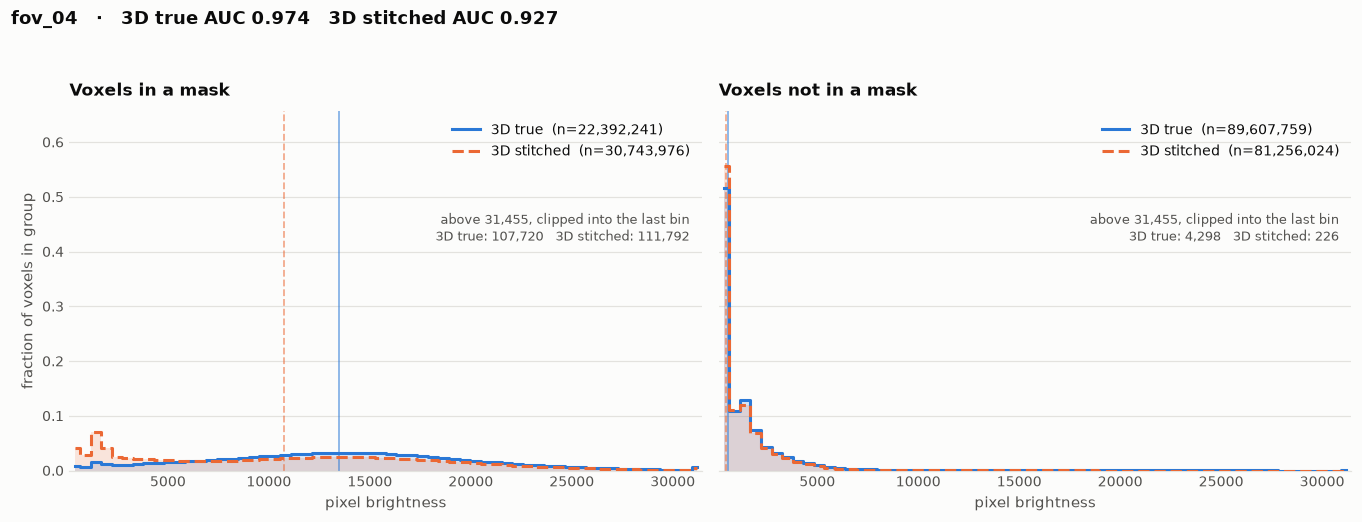

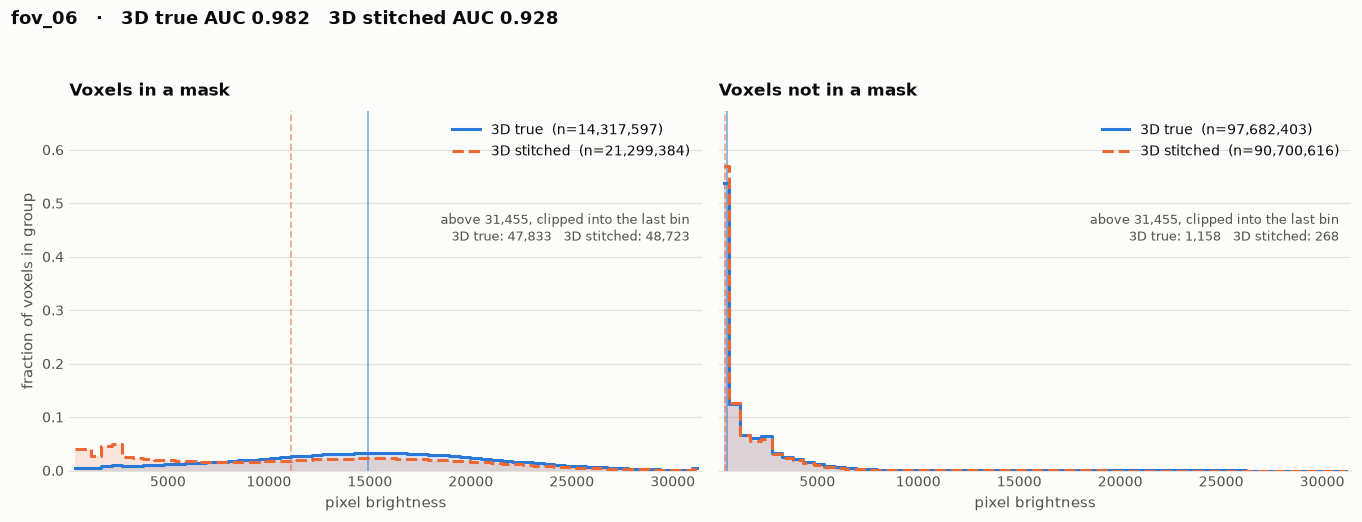

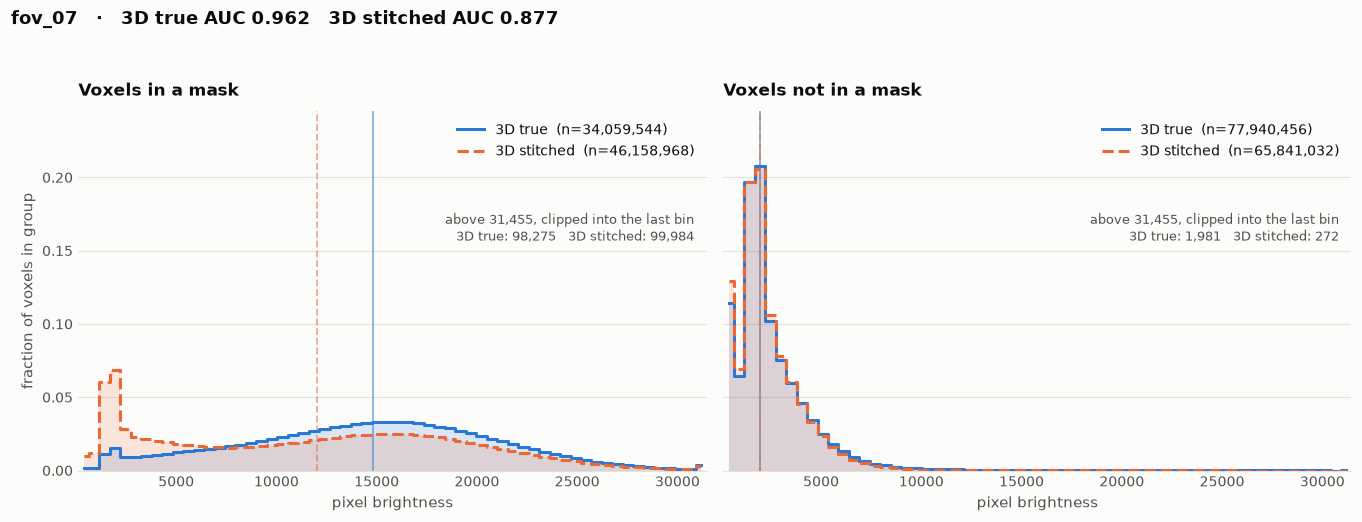

In [18]:
# --- 3b. one figure per FOV ---------------------------------------------------
figures = bh.plot_region_brightness(
    runs, metrics=metrics,
    share_x=SHARE_X, share_y=SHARE_Y,
    n_bins=N_DISPLAY_BINS, clip_quantile=CLIP_QUANTILE, log_y=LOG_Y,
)

### Region UWA-7648

In [19]:
# --- 4a. every FOV in the region, under both techniques ----------------------
SCAN_REGION = "region_UWA-7648"

found = h.find_region_fovs(TECHNIQUE_ROOTS, SCAN_REGION)
print(f"\n{found['fov'].nunique()} paired FOV(s) in {SCAN_REGION}\n")

runs = bh.scan_region_brightness(found, DAPI_PATCHES / SCAN_REGION)
metrics = bh.brightness_metrics(runs)

metrics[METRIC_COLUMNS].round(3)


3 paired FOV(s) in region_UWA-7648

  fov_01     3D true       1,421,152 masked voxels ( 1.27%)
  fov_01     3D stitched   2,382,192 masked voxels ( 2.13%)
  fov_07     3D true      36,777,988 masked voxels (32.84%)
  fov_07     3D stitched  51,073,288 masked voxels (45.60%)
  fov_09     3D true      24,495,098 masked voxels (21.87%)
  fov_09     3D stitched  35,616,109 masked voxels (31.80%)


frac_masked  median_masked  median_unmasked    auc  point_biserial_r
fov    method                                                                           
fov_01 3D true            0.013      12654.608          278.841  0.963             0.795
       3D stitched        0.021       5548.321          276.289  0.868             0.667
fov_07 3D true            0.328      14667.620         2032.539  0.953             0.790
       3D stitched        0.456      12284.364         1808.499  0.888             0.681
fov_09 3D true            0.219       8681.127          943.863  0.961             0.756
       3D stitched        0.318       7079.110          786.511  0.926             0.708

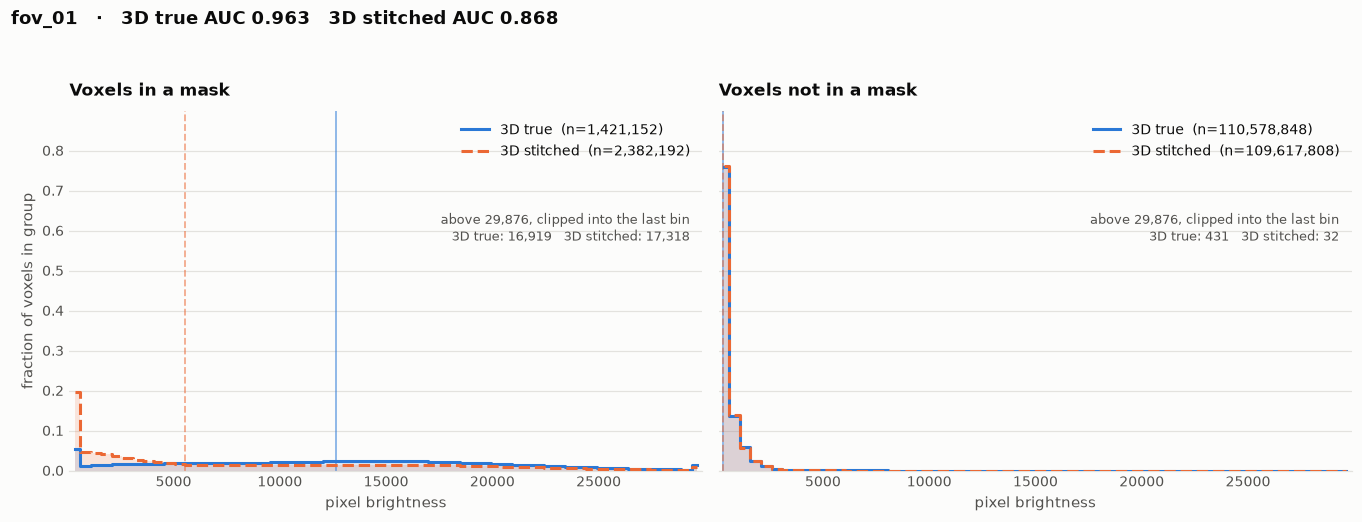

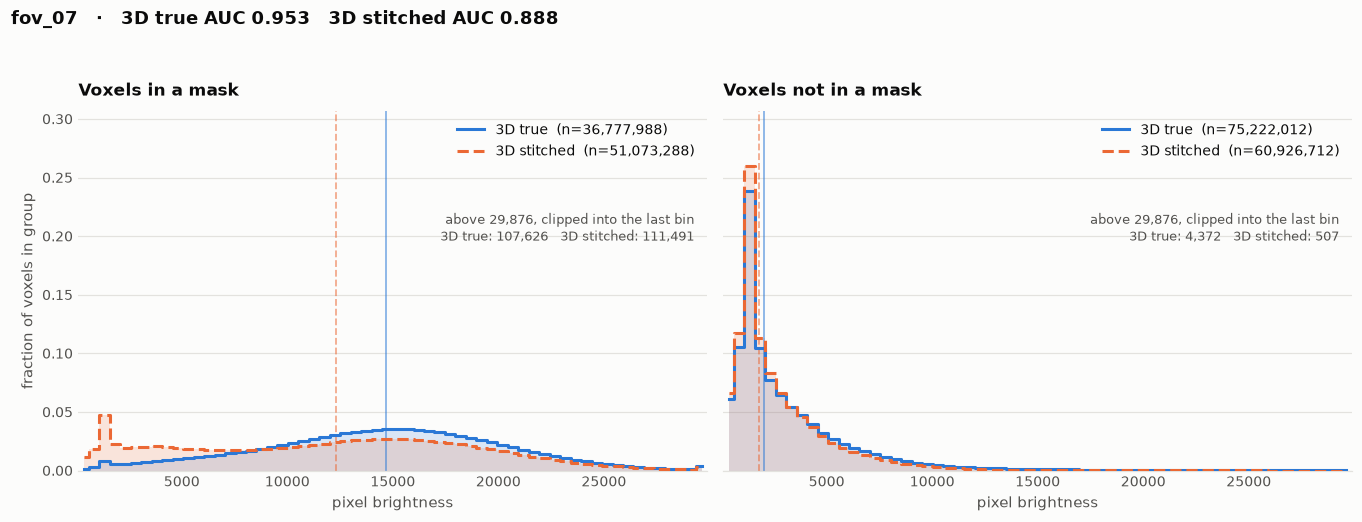

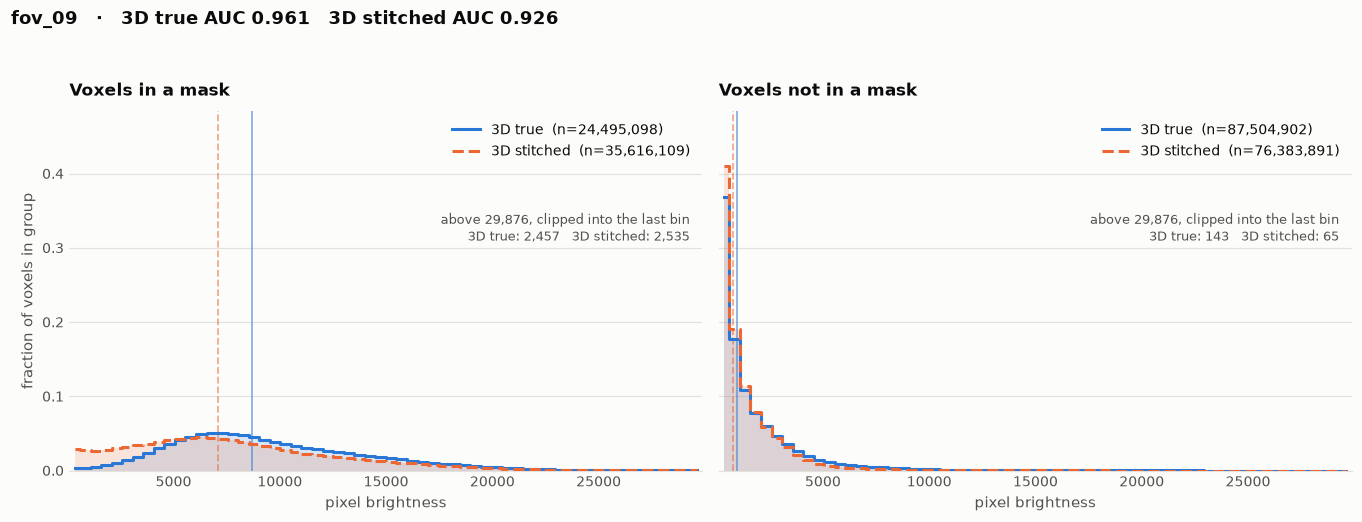

In [20]:
# --- 4b. one figure per FOV ---------------------------------------------------
figures = bh.plot_region_brightness(
    runs, metrics=metrics,
    share_x=SHARE_X, share_y=SHARE_Y,
    n_bins=N_DISPLAY_BINS, clip_quantile=CLIP_QUANTILE, log_y=LOG_Y,
)

### Looking at one FOV in napari

Set `NAPARI_REGION` and `NAPARI_FOV` in the cell below — it reads that pair on
its own, so it does not matter which region block above you ran last, or whether
you ran one at all. Name a FOV that is not paired in that region and it says
which ones are.

Per technique, two derived volumes on top of the DAPI and its masks:

* **bright, unmasked** — outside every mask yet brighter than the median masked
  voxel. Signal that technique left behind.
* **dim, masked** — inside a mask yet dimmer than the median unmasked voxel.
  Background it pulled in.

Thresholds are per technique, since each one's own distribution is what defines
bright and dim for it — which is why the stitched thresholds come out lower.
Both derived layers start hidden.

In [4]:
# --- 5a. pick a region and a FOV, then build the layers (safe to run headless) -
NAPARI_REGION = "region_UCI-5224"
NAPARI_FOV    = "fov_07"

focus_dapi, focus_masks, focus_edges, focus_counts = bh.load_fov(
    TECHNIQUE_ROOTS, DAPI_PATCHES, NAPARI_REGION, NAPARI_FOV)

focus_layers = bh.build_overlap_layers(
    focus_dapi, focus_masks, focus_edges, focus_counts)

for method, entry in focus_layers.items():
    print(f"{NAPARI_REGION}  {NAPARI_FOV}  {method:<12} "
          f"{int(entry['bright_unmasked'].sum()):>9,} bright-but-unmasked "
          f"(>{entry['bright_thr']:,.0f})   "
          f"{int(entry['dim_masked'].sum()):>8,} dim-but-masked "
          f"(<{entry['dim_thr']:,.0f})")

region_UCI-5224  fov_07  3D true        403,994 bright-but-unmasked (>14,806)    803,191 dim-but-masked (<1,954)
region_UCI-5224  fov_07  3D stitched    113,153 bright-but-unmasked (>12,012)   5,323,841 dim-but-masked (<1,949)


In [5]:
# --- 5b. two viewers, one per technique ---------------------------------------
# Blocks the kernel until BOTH windows are closed.
viewers = bh.launch_viewer(focus_dapi, focus_masks, focus_layers,
                           title=f"{NAPARI_REGION} {NAPARI_FOV}")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
